# Assingment 4 - Stroke Prediction

***In order to subimt your assigment, please follow these instructions carefully:***

1. It's recommended to run this notebook in the DOORS platform, or, if you know what you're doing (or need another module, though you can also locally install modules with `!pip install`, but beware that they might disappear). (It is not necessary to install new packages, but you can if you find them useful for the completion of this assignment.
2. Once you are done with the assignment, make sure to restart the Kernel and run all to ensure that eveything runs in sequence and that you don't have errors.
3. When you're done with the steps, save the notebook and also save the notebook as PDF (File > Save/Export (depnding on the Jupyter version) > PDF). Upload the PDF in UNESS. You can also upload the ipynb once you've saved it (you can get it from File > Download).

***Please don't forget to tell me who you are:***

**NAME: Thanh-Phuong VO**

**EMAIL: Thanh-Phuong.Vo@etu.univ-grenoble-alpes.fr; 0001thanhphuong@gmail.com**


Notes:
- While doing this assigment, try also to go a bit "beyond" what's being asked, i.e. show the process which you follow and how you approach the problem.
- Look online for ways to get what you want from insights (i.e. how to check a model's performance while training)
- Feel free to check other tutorials and assignments to get ideas for algorithms
- If you copy something from somewhere, you should reference it properly and explain what it does (also for your code)

In this assignment, we'll use a stroke prediction dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns    

In [2]:
stroke_df = pd.read_csv('data/stroke-data.csv')
stroke_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [3]:
stroke_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
# Checking for missing entries

total_entries = len(stroke_df)
bmi_number_of_missing = stroke_df.bmi.isnull().sum()
smoke_number_of_missing = stroke_df.smoking_status.isnull().sum()
bmi_missing_percent = 100*bmi_number_of_missing/total_entries
smoke_missing_percent = 100*smoke_number_of_missing/total_entries

print(f"Missing entries details:\n")
print(f"bmi has {bmi_number_of_missing:.2f} ({bmi_missing_percent:.2f}%) missing values.")
print(f"smoking_status has {smoke_number_of_missing} ({smoke_missing_percent}%) missing values")

Missing entries details:

bmi has 201.00 (3.93%) missing values.
smoking_status has 0 (0.0%) missing values


The ID doesn't seem relevant: we drop it from the data.

In [5]:
stroke_df = stroke_df.drop(columns=['id'])

We now look a bit more into our dataset, checking how many unique values our entries have.

In [6]:
stroke_df.nunique()

gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
stroke                  2
dtype: int64

We can see from the number of distinct information that some entries are likely:
- Categorical: `gender`, `work_type`, `smoking_status`, and `Residence_type`
- Boolean (yes/no): `hypertension`, `heart_disease`, and `ever_married` (and of course the target, `stroke`)
- Numerical: `age`, `avg_glucose_level` and `bmi`

Let's see if that's the case.

In [7]:
for col in stroke_df.columns.values.tolist():
    if col not in [ 'id', 'age', 'avg_glucose_level', 'bmi']:
        print(f"{col}:", stroke_df[col].unique())

gender: ['Male' 'Female' 'Other']
hypertension: [0 1]
heart_disease: [1 0]
ever_married: ['Yes' 'No']
work_type: ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type: ['Urban' 'Rural']
smoking_status: ['formerly smoked' 'never smoked' 'smokes' 'Unknown']
stroke: [1 0]


We were almost right: `ever_married` is not quite a boolean, but a category of two.

Let's now describe the numerical bits:

In [8]:
# Summary stats for numerical columns, i.e [age, avg_glucose_level, bmi]
num_col = ['age', 'avg_glucose_level', 'bmi']
stroke_df[num_col].describe()

,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,4909.000000
mean,43.226614,106.147677,28.893237
std,22.612647,45.283560,7.854067
min,0.080000,55.120000,10.300000
25%,25.000000,77.245000,23.500000
50%,45.000000,91.885000,28.100000
75%,61.000000,114.090000,33.100000
max,82.000000,271.740000,97.600000


We notice that the number of BMI entries (count field) is incomplete (4909 out of 5110, i.e 96%).

We now will prepare our dataset for an ML algorithm.

In [9]:
# We create a copy of the DataFrame to prepare it for our ML/DL activities
stroke_df2 = stroke_df.iloc[:,:].copy()
stroke_df2.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [10]:
# Replacing the BMI values by the median
stroke_df2.bmi.fillna(stroke_df2.bmi.median(), inplace = True)
stroke_df2.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


We continue by converting the categorical information in one-hot encoding.

***Q1 [1pt] What is a "one-hot" encoding and why do we use it ?***

***Answer:*** 

One-hot encoding transforms each categorical feature with n_categories possible values into n_categories binary features, with one of them 1, and all others 0. We use it because many ML models expect numeric inputs, and encoding categories as 0/1/2/… can introduce an artificial ordering and distance that does not exist, potentially biasing the model.

In [11]:
# We encode the labels using boolean/one-hot encoding
stroke_df2 = pd.get_dummies(stroke_df2, columns = ['gender', 'ever_married', 'work_type', 'Residence_type'])
stroke_df2.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban
0,67.0,0,1,228.69,36.6,formerly smoked,1,False,True,False,False,True,False,False,True,False,False,False,True
1,61.0,0,0,202.21,28.1,never smoked,1,True,False,False,False,True,False,False,False,True,False,True,False
2,80.0,0,1,105.92,32.5,never smoked,1,False,True,False,False,True,False,False,True,False,False,True,False
3,49.0,0,0,171.23,34.4,smokes,1,True,False,False,False,True,False,False,True,False,False,False,True
4,79.0,1,0,174.12,24.0,never smoked,1,True,False,False,False,True,False,False,False,True,False,True,False


In [12]:
# We add  a new label 'no_info' for smoking_status missing
stroke_df2.smoking_status.fillna('no info', inplace=True)

In [13]:
# We assign a category to the `smoking_status` column
smoke_map = {'never smoked': 0, 'no info': 1, 'formerly smoked': 2, 'smokes':3}
stroke_df2['smoking_status_code'] = stroke_df2['smoking_status'].map(smoke_map)
stroke_df2.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_code
0,67.0,0,1,228.69,36.6,formerly smoked,1,False,True,False,False,True,False,False,True,False,False,False,True,2.0
1,61.0,0,0,202.21,28.1,never smoked,1,True,False,False,False,True,False,False,False,True,False,True,False,0.0
2,80.0,0,1,105.92,32.5,never smoked,1,False,True,False,False,True,False,False,True,False,False,True,False,0.0
3,49.0,0,0,171.23,34.4,smokes,1,True,False,False,False,True,False,False,True,False,False,False,True,3.0
4,79.0,1,0,174.12,24.0,never smoked,1,True,False,False,False,True,False,False,False,True,False,True,False,0.0


***Q2 [1pt] Why do we need to map the `smoking_status` to numbers ?***

***Answer:*** 

`smoking_status` is text, and most ML algorithms require numerical features. 
Mapping it to numbers makes it usable in training. 
If the mapping is designed to reflect a meaningful progression (e.g., never smoked → formerly smoked → smokes), it can act as an ordinal proxy; otherwise, it can simply be a compact numeric code (though one-hot encoding is often safer when no true order exists).

One last thing we ought to do is remove the feature that don't add anything, i.e. they are just alrady encoded in others.

In [14]:
stroke_df_ML = stroke_df2.drop(columns=['ever_married_No', 'Residence_type_Rural',
                                               'work_type_Never_worked', 'smoking_status'])
stroke_df_ML.info()
stroke_df_ML.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5110 non-null   float64
 1   hypertension             5110 non-null   int64  
 2   heart_disease            5110 non-null   int64  
 3   avg_glucose_level        5110 non-null   float64
 4   bmi                      5110 non-null   float64
 5   stroke                   5110 non-null   int64  
 6   gender_Female            5110 non-null   bool   
 7   gender_Male              5110 non-null   bool   
 8   gender_Other             5110 non-null   bool   
 9   ever_married_Yes         5110 non-null   bool   
 10  work_type_Govt_job       5110 non-null   bool   
 11  work_type_Private        5110 non-null   bool   
 12  work_type_Self-employed  5110 non-null   bool   
 13  work_type_children       5110 non-null   bool   
 14  Residence_type_Urban    

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,ever_married_Yes,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_code
0,67.0,0,1,228.69,36.6,1,False,True,False,True,False,True,False,False,True,2.0
1,61.0,0,0,202.21,28.1,1,True,False,False,True,False,False,True,False,False,0.0
2,80.0,0,1,105.92,32.5,1,False,True,False,True,False,True,False,False,False,0.0
3,49.0,0,0,171.23,34.4,1,True,False,False,True,False,True,False,False,True,3.0
4,79.0,1,0,174.12,24.0,1,True,False,False,True,False,False,True,False,False,0.0


One last step is to normalise/scale certain values.

In [15]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Select numerical columns to scale
numerical_cols_to_scale = ['avg_glucose_level', 'bmi']

# Apply scaling on numerical columns
stroke_df_ML[numerical_cols_to_scale] = scaler.fit_transform(stroke_df_ML[numerical_cols_to_scale])

We have now done enough preprocessing and are ready to train ML/DL methods.

In [16]:
feature_names = stroke_df_ML.drop(columns=['stroke']).columns
target_var = 'stroke'

print(feature_names)
print(target_var)

Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'gender_Female', 'gender_Male', 'gender_Other', 'ever_married_Yes',
       'work_type_Govt_job', 'work_type_Private', 'work_type_Self-employed',
       'work_type_children', 'Residence_type_Urban', 'smoking_status_code'],
      dtype='object')
stroke


In [17]:
X = stroke_df_ML.iloc[:, list(range(5))+list(range(6,15))]
Y = stroke_df_ML.iloc[:, 5]

In [18]:
print(X.shape, Y.shape)

(5110, 14) (5110,)


Let's now train some models.

We split between training and testing samples.

In [19]:
# Splitting between traning and testing
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 0)

# Checking the shapes to get an understanding of the problem
print( X_train.shape, X_test.shape )
print( Y_train.shape, Y_test.shape )

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

(3832, 14) (1278, 14)
(3832,) (1278,)


We introduce this helper function, that:
- trains the model with `X_train` and `Y_train`
- predicts the output of the model of `X_test`
- computes the confusion matrix comparing the prediciton `guesses` with `Y_test`
- displays the confusion matrix

In [20]:
def model_check(model, train=True):
    if train:
        model.fit(X_train, Y_train)

    guesses = model.predict(X_test)
    
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(Y_test, guesses)
    
    from sklearn import metrics
    accuracy = metrics.accuracy_score(Y_test, guesses)
    print(f"Accuracy: {accuracy:.4f}")

    import seaborn as sns
    sns.heatmap(cm, annot=True, fmt='g')
    plt.title("Confusion matrix")
    plt.ylabel('True class')
    plt.xlabel('Predicted class')
    plt.show()
    
    return model # In case we want to do something with it

Try two algorithms from class to solve the problem. (No need to go too fancy in the parameters.)

***Q3 [2pts] Which two algorithms did you try and why did you pick them ? (incl. points for code in two blocks below)***

***Answer:*** 

I tried Logistic Regression and Random Forest:

Logistic Regression is a strong, interpretable baseline for binary classification and can incorporate class imbalance handling via class weights.

Random Forest can capture non-linear relationships and feature interactions, is robust in practice, and can also use class weights to reduce imbalance bias.


Accuracy: 0.7520


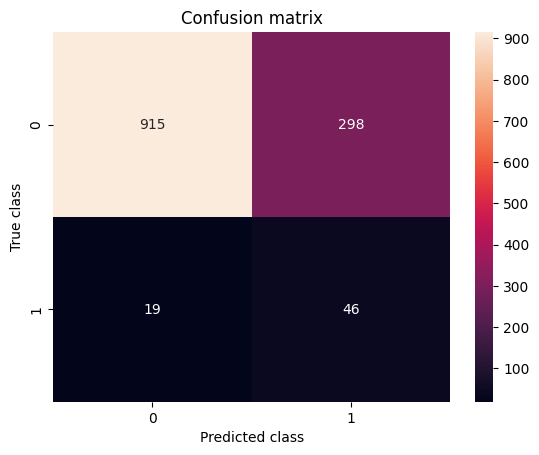

LogisticRegression(class_weight='balanced', random_state=10)

In [21]:
# COMMENT THIS OUT AND ADJUST

# #Add code to import your model
# from XXX import YYY
# #Check the model
# model_check(YYY)
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(max_iter=100, class_weight="balanced", random_state=10)
model_check(model_lr, train=True)

Accuracy: 0.9499


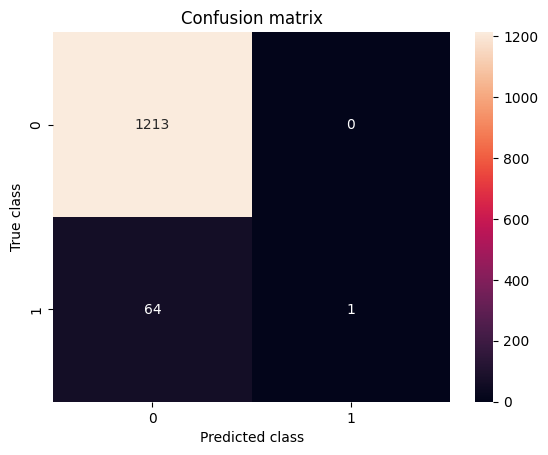

RandomForestClassifier(random_state=10)

In [22]:
# COMMENT THIS OUT AND ADJUST

# #Add code to import your model
# from XXX import YYY
# #Check the model
# model_check(YYY)
from sklearn.ensemble import RandomForestClassifier
# Instantiating a random forest classifier
model_rf = RandomForestClassifier(n_estimators=100, random_state=10)
# Check the model
model_check(model_rf, train=True)

***Q4 [2pts] What does the confusion matrix show ? Describe its 4 bins and how they should ideally look like.***

***Answer:*** 

1. A confusion matrix summarizes how predicted labels of the classifier compare to true labels by counting outcomes in 4 bins. It is especially useful because accuracy alone can hide which kinds of errors the model makes.

2. The 4 bins (binary classification)
Assuming class 1 = stroke and class 0 = no stroke:
- True Negative (TN): true 0, predicted 0 → correctly predicted no stroke
- False Positive (FP): true 0, predicted 1 → “false alarm” (predict stroke when there isn’t one)
- False Negative (FN): true 1, predicted 0 → missed stroke (most critical error in many medical settings)
- True Positive (TP): true 1, predicted 1 → correctly predicted stroke

3. The confusion matrix should ideally look 
- Large values on the diagonal (TN and TP) → many correct predictions
- Small values off-diagonal (FP and FN) → few mistakes
In stroke detection, we usually want FN as low as possible (high recall/sensitivity), because missing a true stroke case can be costly, we then try to control FP to avoid too many unnecessary alarms.

Let us now try with a neural network.

In [23]:
import tensorflow as tf
nn_model = tf.keras.models.Sequential([
  tf.keras.layers.Dense(10, activation=tf.nn.relu, input_dim=14),
  tf.keras.layers.Dense(10, activation=tf.nn.relu),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(1, activation=tf.nn.sigmoid) # Sigmoid to limit output between 0 and 1
])

nn_model.compile(optimizer='adam',
              loss='mean_squared_error',
              metrics=['accuracy'])
nn_model.fit(X_train, Y_train, batch_size = 50, epochs=5)

2025-12-19 22:53:42.741919: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-19 22:53:42.787510: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-19 22:53:42.787566: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-19 22:53:42.789212: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-19 22:53:42.797092: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-19 22:53:42.798055: I tensorflow/core/platform/cpu_feature_guard.cc:1

Epoch 1/5
77/77 [==============================] - 1s 2ms/step - loss: 0.1011 - accuracy: 0.9371
Epoch 2/5
77/77 [==============================] - 0s 2ms/step - loss: 0.0610 - accuracy: 0.9512
Epoch 3/5
77/77 [==============================] - 0s 2ms/step - loss: 0.0518 - accuracy: 0.9520
Epoch 4/5
77/77 [==============================] - 0s 2ms/step - loss: 0.0483 - accuracy: 0.9520
Epoch 5/5
77/77 [==============================] - 0s 2ms/step - loss: 0.0466 - accuracy: 0.9520


Checking again the confusion matrix. (It's slightly different because of how the network outputs its predicition.)

40/40 [==============================] - 0s 840us/step


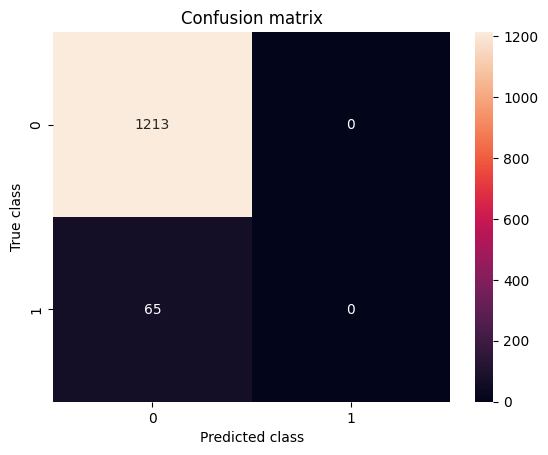

In [24]:
def nn_model_check(nn_model, threshold=0.5):
    nn_model.evaluate(X_test, Y_test)

    Y_pred = nn_model.predict(X_test)
    Y_pred = [ 1 if y>=threshold else 0 for y in Y_pred]

    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(Y_test, Y_pred)

    import seaborn as sns
    sns.heatmap(cm, annot=True, fmt='g')
    plt.title("Confusion matrix")
    plt.ylabel('True class')
    plt.xlabel('Predicted class')
    plt.show()
    
nn_model_check(nn_model)

***Q5 [1pt] How does it compare to the other algorithms you trained ? What's not ideal with the NN model trained above ?***

***Answer:*** 

Compared to your Logistic Regression and Random Forest, the NN performs much worse for the clinically important class (stroke = 1), even though its accuracy looks high.
- Logistic Regression: it predicts both classes (has non-zero TP), but still makes many FP and FN.
- Random Forest: best overall here (very few FP and FN = 0, so it detects strokes well).
- Neural Network (your result): the confusion matrix shows it predicts only class 0: TN = 1213, FP = 0, FN = 65, TP = 0

The not ideal with the NN is that:
- The NN has TP = 0, meaning it fails to detect any stroke cases (class 1). Therefore, recall/sensitivity for stroke is 0, which is unacceptable for a screening/detection task.
- The high accuracy (~0.95) is misleading because, in an imbalanced dataset, a model can get high accuracy by always predicting the majority class (no stroke).

Let us try to resample the data.

In [25]:
# Upsampling Data

columns = stroke_df_ML.columns
print(columns)

from sklearn.utils import resample
st_0 = stroke_df_ML.loc[stroke_df_ML['stroke']==0]
st_1 = stroke_df_ML.loc[stroke_df_ML['stroke']==1]

st_1 = resample(st_1, replace=True, n_samples=st_0.shape[0], random_state=0)

stroke_df_ML_resampled = pd.DataFrame(np.concatenate((st_0, st_1)), columns=columns)
del st_0, st_1

Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'stroke', 'gender_Female', 'gender_Male', 'gender_Other',
       'ever_married_Yes', 'work_type_Govt_job', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban',
       'smoking_status_code'],
      dtype='object')


In [26]:
stroke_df_ML_resampled.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,ever_married_Yes,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_code
0,3.0,0,0,-0.243549,-1.410872,0,False,True,False,False,False,False,False,True,False,NaN
1,58.0,1,0,-0.401679,1.342801,0,False,True,False,True,False,True,False,False,True,0.0
2,8.0,0,0,0.104735,-1.462828,0,True,False,False,False,False,True,False,False,True,NaN
3,70.0,0,0,-0.819532,0.914163,0,True,False,False,True,False,True,False,False,False,2.0
4,14.0,0,0,1.21761,-1.267993,0,False,True,False,False,False,False,False,False,False,NaN


In [27]:
stroke_df_ML_resampled.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,ever_married_Yes,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_code
count,9722.0,9722,9722,9722.000000,9722.000000,9722,9722,9722,9722,9722,9722,9722,9722,9722,9722,7311.0
unique,104.0,2,2,3979.000000,418.000000,2,2,2,2,2,2,2,2,2,2,3.0
top,78.0,0,0,-0.103749,-0.098981,0,True,False,False,True,False,True,False,False,True,0.0
freq,521.0,7988,8556,56.000000,999.000000,4861,5562,5563,9721,7438,8464,5710,7706,9006,5130,3570.0


In [28]:
X_resampled = stroke_df_ML_resampled.iloc[:, list(range(5))+list(range(6,15))]
Y_resampled = stroke_df_ML_resampled.iloc[:, 5].astype(int)
print(X_resampled.shape, Y_resampled.shape)

(9722, 14) (9722,)


***Note, we replace the previously set `X_train`, `X_test`, `Y_train`, `Y_test`. You need to restart the kernel or adjust the variable names if you want to keep re-using them after that!!***

In [29]:
# Splitting between traning and testing
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_resampled, Y_resampled, test_size = 0.25, random_state = 0)

# Checking the shapes to get an understanding of the problem
print( X_train.shape, X_test.shape )
print( Y_train.shape, Y_test.shape )

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

(7291, 14) (2431, 14)
(7291,) (2431,)


Accuracy: 0.9186


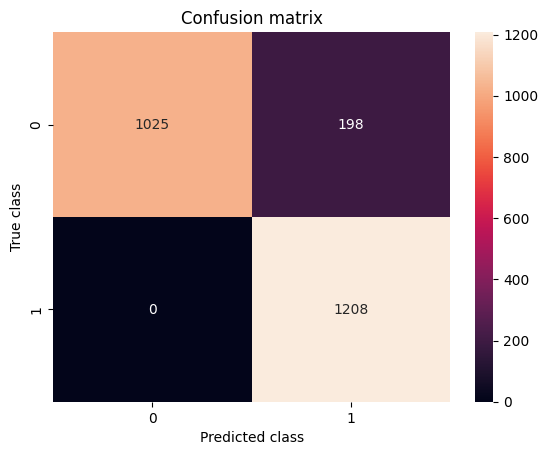

In [30]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = model_check(KNeighborsClassifier())

***Q6 [2pts] Why is the output here significantly different ? Why do we resample ? What's the benefit of doing this ?***

***Answer:*** 

The output is significantly different because resampling changes the class distribution in the training data, so the model no longer learns a decision rule dominated by the majority class.
- Before resampling (original data): the dataset is highly imbalanced (far more “no stroke” than “stroke”). Many models can achieve decent accuracy by mostly predicting the majority class, which often leads to more false negatives (missed strokes).
- After resampling (balanced data): the number of minority-class samples (stroke=1) was artificially increased, so the model is forced to pay attention to patterns of the stroke class. This typically shifts the decision boundary toward detecting more positives.

In resampled confusion matrix:
- FN = 0 (it missed no stroke cases)
- TP = 1208 (it correctly found many stroke cases)

Trade-off: FP = 198 (more false alarms than a conservative model)

The benefit of resampling: it usually improves recall/sensitivity for the minority class (stroke), which is often the most important objective in medical screening. However, it can increase false positives, because the model is more willing to predict “stroke”.

***Q7 [1pt] Can you run another model with the resampling ? What do you conclude ?***

***Answer:*** 
I retrained another model, a neural network, using the resampled dataset. Compared to the NN trained on the original imbalanced data (which predicted only class 0 and had TP = 0), the resampled NN now predicts both classes and successfully detects stroke cases (TP = 1019).

From the resampled confusion matrix: TN = 873, FP = 350, FN = 189, TP = 1019, accuracy ≈ 0.7783.

In conclusion, resampling makes the model much more sensitive to the minority class (stroke=1), it no longer collapses to predicting only “no stroke”. The trade-off is that the model becomes more liberal in predicting stroke, leading to more false positives and potentially a lower overall accuracy. This is expected in imbalanced classification that resampling typically improves minority-class detection (TP) but can reduce precision and accuracy.

Epoch 1/5
146/146 [==============================] - 1s 2ms/step - loss: 0.2387 - accuracy: 0.5983
Epoch 2/5
146/146 [==============================] - 0s 2ms/step - loss: 0.1922 - accuracy: 0.7048
Epoch 3/5
146/146 [==============================] - 0s 2ms/step - loss: 0.1765 - accuracy: 0.7409
Epoch 4/5
146/146 [==============================] - 0s 2ms/step - loss: 0.1703 - accuracy: 0.7546
Epoch 5/5
76/76 [==============================] - 0s 839us/step


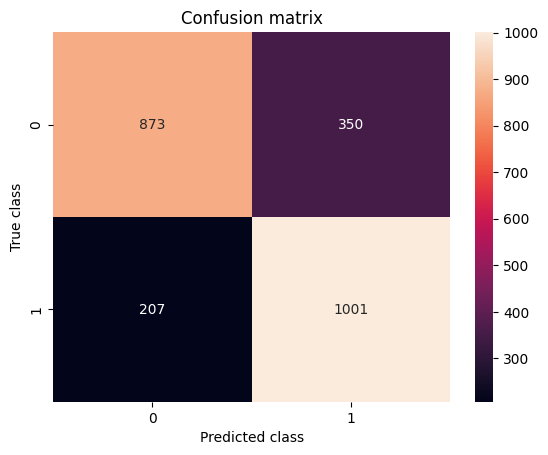

In [31]:
# COMMENT THIS OUT AND ADJUST

# #Add code to import your model
# from XXX import YYY
# #Check the model
# model_check(YYY)
import tensorflow as tf
nn_model_re = tf.keras.models.Sequential([
  tf.keras.layers.Dense(10, activation=tf.nn.relu, input_dim=14),
  tf.keras.layers.Dense(10, activation=tf.nn.relu),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(1, activation=tf.nn.sigmoid) # Sigmoid to limit output between 0 and 1
])

nn_model_re.compile(optimizer='adam',
              loss='mean_squared_error',
              metrics=['accuracy'])
nn_model_re.fit(X_train, Y_train, batch_size = 50, epochs=5)

nn_model_check(nn_model_re)

# Wrapping up

*Note: use this space for thoughts; this part is not part of the mark (unless you don't fill it at all).*

What did you take out from this?

**Answer:**

What I took away from this assignment are:

1. Preprocessing matters as much as the model: The processing data includes (1) drop non-informative IDs, (2) handle missing BMI values, (3) encode categorical variables (one-hot + smoking-status mapping), and (4) scale numerical features before training models. Without these steps, many algorithms (especially distance-based and neural networks) won’t behave properly. 

2. Accuracy can be misleading - confusion matrices tell the real story: The neural network initially achieved 0.95 accuracy but predicted only class 0 (no stroke), giving TP = 0 and FN > 0, meaning it failed to detect any stroke cases. This showed me why we must inspect TN/FP/FN/TP, not just accuracy. 

3. Class imbalance drives model behavior, and resampling changes everything: After resampling, models started detecting the minority class much better. The benefit is higher sensitivity/recall for stroke, but the trade-off is often more false positives (more “false alarms”). 

4. Simple ML baselines can outperform a basic NN on tabular data: Logistic Regression and Random Forest were strong baselines; in my runs, Random Forest achieved very strong performance with very few errors compared to the NN baseline. This reinforced the idea that “deep learning” isn’t automatically better-architecture and data type matter. 

5. Model choice should match the clinical goal: For stroke prediction, missing a true stroke (FN) is usually more costly than raising a false alarm (FP). So I learned to prioritize reducing FN / improving recall and to interpret results through that lens (and not only by overall accuracy).